In [1]:
import pandas as pd

df = pd.read_csv("Airbnb2.csv")

df.head()

,Address,ISHostedBySuperhost,Location/lat,Location/lng,Name,NumberOfGuests,Pricing,RoomType,Stars
0,"Manali, Himachal Pradesh, India",False,32.22330,77.18228,HighQ Manali / Deluxe Room,3,8946,Room in hotel,NaN
1,"Manali, Himachal Pradesh, India",False,32.22352,77.18152,Highq manali / 3 BHK Cottage,9,9124,Room in hotel,NaN
2,"Goa, India",False,15.50400,73.86600,Best view of the river from your terrace 04,4,9900,Private room in home,4.00
3,"Bhuntar, Himachal Pradesh, India",False,31.88656,77.14467,Shabashe,1,8684,Shared room in rental unit,NaN
4,"Jaipur, Rajasthan, India",False,26.85991,75.66909,Luxurious Independent Studio with Wifi & Kitchen,1,20690,Entire condo,4.75


In [2]:
df.columns

Index(['Address', 'ISHostedBySuperhost', 'Location/lat', 'Location/lng',
       'Name', 'NumberOfGuests', 'Pricing', 'RoomType', 'Stars'],
      dtype='str')

In [3]:
df = df[[
    "Address",
    "RoomType",
    "Pricing",
    "NumberOfGuests",
    "Stars",
    "Location/lat",
    "Location/lng"
]]

In [4]:
df.head()

,Address,RoomType,Pricing,NumberOfGuests,Stars,Location/lat,Location/lng
0,"Manali, Himachal Pradesh, India",Room in hotel,8946,3,NaN,32.22330,77.18228
1,"Manali, Himachal Pradesh, India",Room in hotel,9124,9,NaN,32.22352,77.18152
2,"Goa, India",Private room in home,9900,4,4.00,15.50400,73.86600
3,"Bhuntar, Himachal Pradesh, India",Shared room in rental unit,8684,1,NaN,31.88656,77.14467
4,"Jaipur, Rajasthan, India",Entire condo,20690,1,4.75,26.85991,75.66909


In [5]:
df["Pricing"].head()

0     8946
1     9124
2     9900
3     8684
4    20690
Name: Pricing, dtype: int64

In [6]:
df.isnull().sum()

Address             0
RoomType            0
Pricing             0
NumberOfGuests      0
Stars             304
Location/lat        0
Location/lng        0
dtype: int64

In [7]:
df["Stars"] = df["Stars"].fillna(df["Stars"].mean())

In [8]:
df.head()

,Address,RoomType,Pricing,NumberOfGuests,Stars,Location/lat,Location/lng
0,"Manali, Himachal Pradesh, India",Room in hotel,8946,3,4.650204,32.22330,77.18228
1,"Manali, Himachal Pradesh, India",Room in hotel,9124,9,4.650204,32.22352,77.18152
2,"Goa, India",Private room in home,9900,4,4.000000,15.50400,73.86600
3,"Bhuntar, Himachal Pradesh, India",Shared room in rental unit,8684,1,4.650204,31.88656,77.14467
4,"Jaipur, Rajasthan, India",Entire condo,20690,1,4.750000,26.85991,75.66909


In [9]:
df["Address"] = df["Address"].str.strip()
df["RoomType"] = df["RoomType"].str.strip()

In [11]:
df.columns = ["Location", "Room Type", "Price", "Guests", "Rating","Location/lat","Location/lng"]

In [12]:
df.head()

,Location,Room Type,Price,Guests,Rating,Location/lat,Location/lng
0,"Manali, Himachal Pradesh, India",Room in hotel,8946,3,4.650204,32.22330,77.18228
1,"Manali, Himachal Pradesh, India",Room in hotel,9124,9,4.650204,32.22352,77.18152
2,"Goa, India",Private room in home,9900,4,4.000000,15.50400,73.86600
3,"Bhuntar, Himachal Pradesh, India",Shared room in rental unit,8684,1,4.650204,31.88656,77.14467
4,"Jaipur, Rajasthan, India",Entire condo,20690,1,4.750000,26.85991,75.66909


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.dtypes

Location            str
Room Type           str
Price             int64
Guests            int64
Rating          float64
Location/lat    float64
Location/lng    float64
dtype: object

In [18]:
df["Room Type"].value_counts()

Room Type
Entire villa                         220
Farm stay                             58
Entire home                           49
Entire bungalow                       29
Room in hotel                         19
Private room in resort                13
Room in boutique hotel                12
Private room in villa                 11
Private room in bed and breakfast      9
Entire condo                           8
Entire cottage                         7
Entire rental unit                     7
Houseboat                              6
Entire chalet                          5
Entire serviced apartment              4
Room in heritage hotel                 4
Boat                                   3
Entire place                           3
Room in serviced apartment             3
Private room in bungalow               3
Private room in home                   2
Private room in castle                 2
Private room in nature lodge           2
Room in resort                         2
Castle

In [19]:
def simplify_room_type(x):
    x = x.lower()
    
    if "entire" in x:
        return "Entire Place"
    elif "private room" in x:
        return "Private Room"
    elif "shared room" in x:
        return "Shared Room"
    else:
        return "Hotel/Other"

df["Room Type"] = df["Room Type"].apply(simplify_room_type)

In [20]:
df["Room Type"].value_counts()

Room Type
Entire Place    336
Hotel/Other     114
Private Room     48
Shared Room       2
Name: count, dtype: int64

In [21]:
df["Location"].head(10)

0     Manali, Himachal Pradesh, India
1     Manali, Himachal Pradesh, India
2                          Goa, India
3    Bhuntar, Himachal Pradesh, India
4            Jaipur, Rajasthan, India
5    Bhuntar, Himachal Pradesh, India
6    Bhuntar, Himachal Pradesh, India
7            Gurugram, Haryana, India
8          Ganaheda, Rajasthan, India
9     Banjar, Himachal Pradesh, India
Name: Location, dtype: str

In [22]:
df["City"] = df["Location"].str.split(",").str[0]

In [23]:
df[["Location", "City"]].head()

,Location,City
0,"Manali, Himachal Pradesh, India",Manali
1,"Manali, Himachal Pradesh, India",Manali
2,"Goa, India",Goa
3,"Bhuntar, Himachal Pradesh, India",Bhuntar
4,"Jaipur, Rajasthan, India",Jaipur


In [27]:
df.columns

Index(['Room Type', 'Price', 'Guests', 'Rating', 'Location/lat',
       'Location/lng', 'City'],
      dtype='str')

In [28]:
df = df[["City", "Room Type", "Price", "Guests", "Rating","Location/lat","Location/lng"]]

In [29]:
df.head()

,City,Room Type,Price,Guests,Rating,Location/lat,Location/lng
0,Manali,Hotel/Other,8946,3,4.650204,32.22330,77.18228
1,Manali,Hotel/Other,9124,9,4.650204,32.22352,77.18152
2,Goa,Private Room,9900,4,4.000000,15.50400,73.86600
3,Bhuntar,Shared Room,8684,1,4.650204,31.88656,77.14467
4,Jaipur,Entire Place,20690,1,4.750000,26.85991,75.66909


In [30]:
df.groupby("City")["Price"].mean().sort_values(ascending=False).head(10)

City
Amritsar Cantt.    36079.000000
Kolkata             6013.000000
Bhuntar             5744.000000
Govind Nagar        5274.000000
Kasol               4470.000000
Khoohdi             4444.000000
Patna               4418.000000
Ramgarh             4381.000000
Janedghat           4351.000000
Vijayawada          3038.333333
Name: Price, dtype: float64

#Key Insights#
✅ Insight 1: Price varies heavily by city
Big difference between cities
Location is a major pricing factor
⚠️ Insight 2: Outlier present
Amritsar Cantt. distorts data
Will break your charts
✅ Insight 3: Most cities fall in ₹3k–₹6k range



In [31]:
df = df[df["Price"] < 20000] #bcz above 20k is unreal value
#dropping outlier

In [32]:
df.groupby("City")["Price"].mean().sort_values(ascending=False).head(10)

City
Kolkata         6013.000000
Bhuntar         5744.000000
Govind Nagar    5274.000000
Kasol           4470.000000
Khoohdi         4444.000000
Patna           4418.000000
Ramgarh         4381.000000
Janedghat       4351.000000
Vijayawada      3038.333333
India           3007.000000
Name: Price, dtype: float64

In [33]:
df = df[df["City"] != "India"] #removing invalid city "india"

In [34]:
df.groupby("City")["Price"].mean().sort_values(ascending=False).head(10)

City
Kolkata         6013.000000
Bhuntar         5744.000000
Govind Nagar    5274.000000
Kasol           4470.000000
Khoohdi         4444.000000
Patna           4418.000000
Ramgarh         4381.000000
Janedghat       4351.000000
Vijayawada      3038.333333
Banjar          2822.000000
Name: Price, dtype: float64

In [35]:
df.describe()

,Price,Guests,Rating,Location/lat,Location/lng
count,497.000000,497.000000,497.000000,497.000000,497.000000
mean,823.450704,11.595573,4.651815,19.641171,74.948999
std,1101.927667,4.510675,0.242683,6.486109,7.119942
min,129.000000,1.000000,2.330000,9.418870,-73.750710
25%,433.000000,8.000000,4.650204,15.526670,73.747000
50%,505.000000,12.000000,4.650204,17.918240,73.803950
75%,722.000000,16.000000,4.670000,26.618880,77.021460
max,9900.000000,16.000000,5.000000,34.090910,92.991610


✅ Pricing Insight
Majority listings fall between ₹400–₹700
Few premium listings go up to ₹9900
✅ Location Insight
Cities like Kolkata and Bhuntar have higher average prices
Smaller cities show moderate pricing
✅ Capacity Insight
Listings are optimized for groups (avg ~12 guests)

✅ Quality Insight
Airbnb listings in dataset have high ratings (~4.6)

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

In [52]:
price_by_city = df.groupby("City")["Price"].mean().sort_values(ascending=False).head(10)

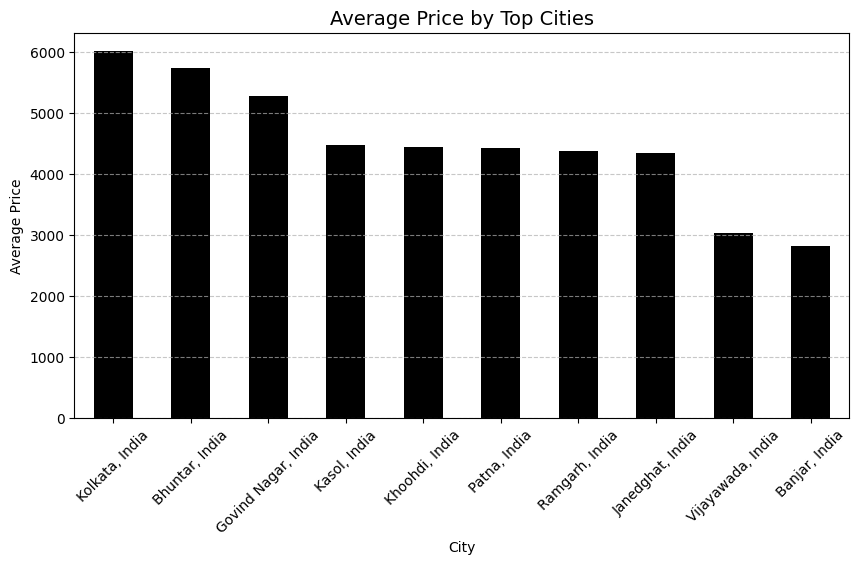

In [51]:
plt.figure(figsize=(10,5))
price_by_city.plot(kind='bar', color='black')

plt.title("Average Price by Top Cities", fontsize=14)
plt.xlabel("City")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

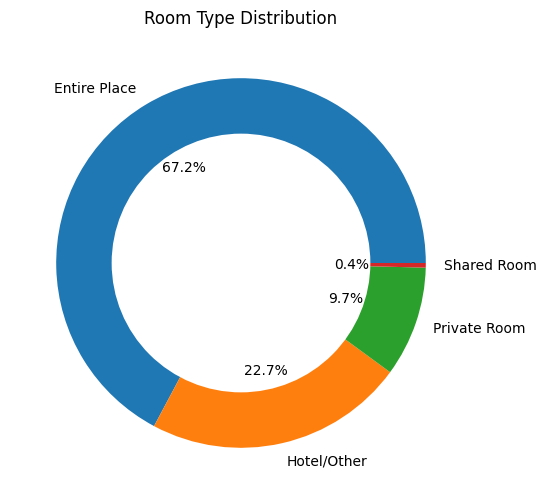

In [38]:
room_counts = df["Room Type"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(room_counts, labels=room_counts.index, autopct='%1.1f%%')

# donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Room Type Distribution")

plt.show()

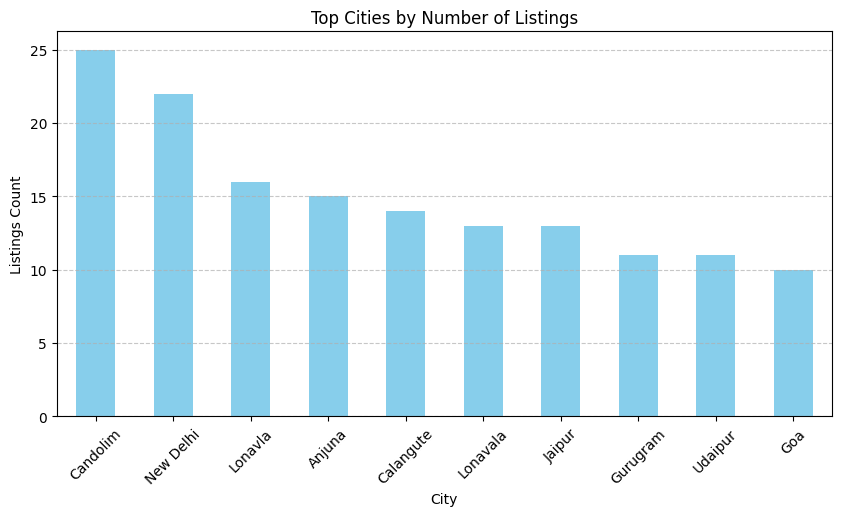

In [39]:
city_counts = df["City"].value_counts().head(10)

plt.figure(figsize=(10,5))
city_counts.plot(kind='bar', color='skyblue')

plt.title("Top Cities by Number of Listings")
plt.xlabel("City")
plt.ylabel("Listings Count")
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

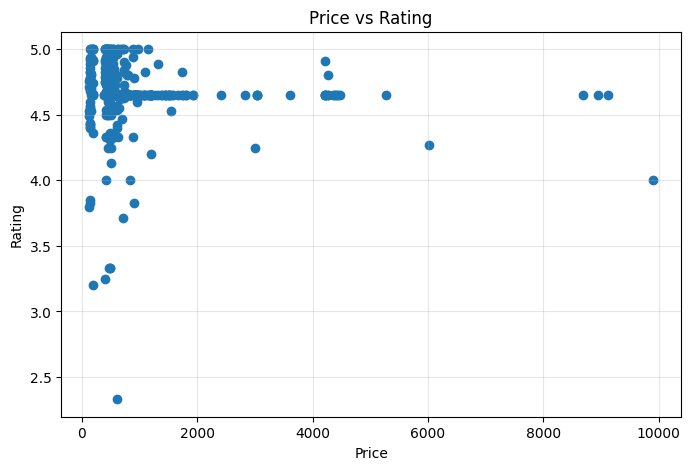

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(df["Price"], df["Rating"])

plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")

plt.grid(alpha=0.3)

plt.show()

There is no strong correlation between price and rating. Even lower-priced listings maintain high ratings, indicating that affordability does not compromise quality.”

In [53]:
df.columns

Index(['City', 'Room Type', 'Price', 'Guests', 'Rating', 'Location/lat',
       'Location/lng', 'Location'],
      dtype='str')

In [54]:
df = df.rename(columns={
    "Location/lat": "lat",
    "Location/lng": "lng"
})

In [55]:
df = df.drop(columns=["Location"])

In [56]:
df.columns

Index(['City', 'Room Type', 'Price', 'Guests', 'Rating', 'lat', 'lng'], dtype='str')

In [57]:
df[["lat", "lng"]].isnull().sum()

lat    0
lng    0
dtype: int64

In [58]:
df[["lat", "lng"]].head()

,lat,lng
0,32.22330,77.18228
1,32.22352,77.18152
2,15.50400,73.86600
3,31.88656,77.14467
5,32.01248,77.29114


In [59]:
df.to_csv("airbnb_cleaned.csv", index=False)